# 트리 모델로 타이타닉 생존자 분류하기

이전 로지스틱 회귀 실습([5. xal_titanic.ipynb](5.%20xal_titanic.ipynb))에서 썼던 것과 같은 **Titanic** 데이터를 그대로 사용합니다.

같은 데이터를 다른 모델(결정 트리)로 학습시켜보면서

- 트리가 어떻게 데이터를 분기해서 분류하는지 **시각화**로 확인하고
- 로지스틱 회귀의 계수(coefficient) 대신 트리 모델은 **변수 중요도(feature importance)** 로 어떤 변수를 중요하게 봤는지 확인합니다.


## 1. 데이터 불러오기 & 전처리

전처리는 저번 로지스틱 회귀 실습과 동일하게 진행합니다 (같은 조건에서 두 모델을 비교하기 위함).

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("Titanic-Dataset.csv")

y = df['Survived']
X = df.drop(columns=['Survived'])

X = X.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Embarked'] = X['Embarked'].map({'S': 1, 'C': 2, 'Q': 3})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
X_train['Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])

X_test['Age'] = X_test['Age'].fillna(X_train['Age'].median())
X_test['Embarked'] = X_test['Embarked'].fillna(X_train['Embarked'].mode()[0])

X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
692,3,0,28.5,0,0,56.4958,1.0
481,2,0,28.5,0,0,0.0000,1.0
527,1,0,28.5,0,0,221.7792,1.0
855,3,1,18.0,0,1,9.3500,1.0
801,2,1,31.0,1,1,26.2500,1.0


## 2. 결정 트리(Decision Tree) 학습

로지스틱 회귀와 다르게 트리 모델은 각 변수의 스케일에 영향을 받지 않기 때문에 별도의 스케일링(정규화)이 필요 없습니다.

트리의 깊이(`max_depth`)를 제한하지 않으면 훈련 데이터를 완벽히 외워버려서(과적합) 시각화도 너무 복잡해지므로, 여기서는 `max_depth=4`로 제한합니다.

In [2]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

model.score(X_test, y_test)

0.7877094972067039

## 3. 평가지표

정확도(accuracy)뿐 아니라 confusion matrix와 f1 score도 함께 봅니다. (로지스틱 회귀 실습에서 본 것과 같은 방식)

F1 score: 0.6607


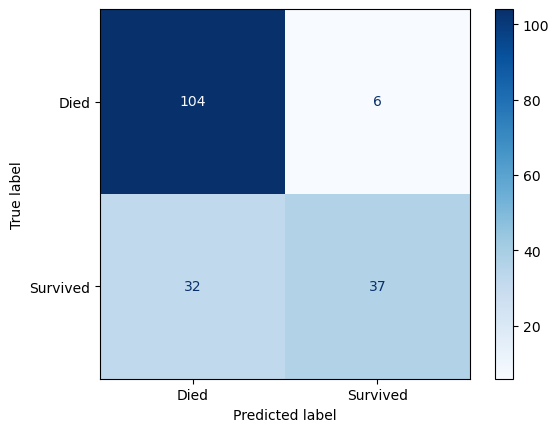

In [3]:
from sklearn.metrics import ConfusionMatrixDisplay, f1_score

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Died', 'Survived'], cmap='Blues')

f1 = f1_score(y_test, y_pred)
print(f"F1 score: {f1:.4f}")

## 4. 트리 시각화

로지스틱 회귀는 "계수"라는 숫자로만 모델을 설명할 수 있었지만, 트리 모델은 **모델이 내린 판단 과정을 그림으로 그대로 볼 수 있다**는 것이 가장 큰 장점입니다.

각 노드는 다음 정보를 담고 있습니다.

- 분기 조건 (예: `Sex <= 0.5`)
- `gini`: 이 노드가 얼마나 순수한지(한 클래스로만 모여 있는지) 나타내는 불순도 지표. 0에 가까울수록 한 클래스로 깨끗하게 나뉜 상태입니다.
- `samples`: 이 노드에 도달한 훈련 데이터 개수
- `value`: [사망자 수, 생존자 수]
- `class`: 이 노드에서 다수를 차지하는 클래스(최종 예측값)

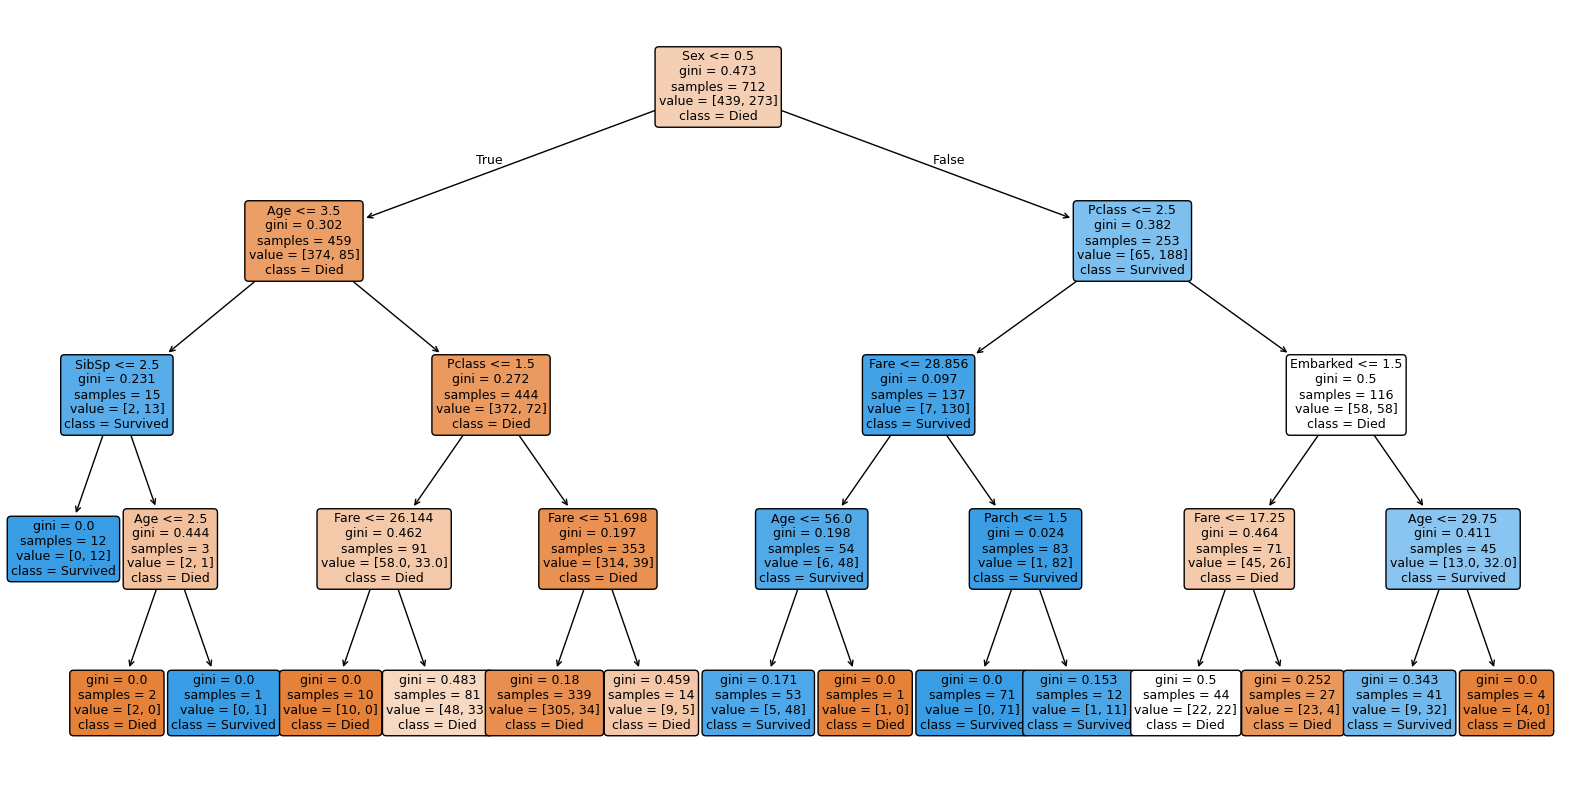

In [4]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X_train.columns,
    class_names=['Died', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.show()

맨 위 root 노드가 `Sex`로 먼저 갈리는 것을 볼 수 있습니다. 트리는 "지금 가진 변수들 중 어떤 것으로 나누면 두 그룹이 가장 순수해지는가(gini가 가장 낮아지는가)"를 매 단계마다 그리디하게 선택하는데, 성별이 생존 여부를 가장 잘 설명하는 변수였다는 뜻입니다.

## 5. 변수 중요도 (Feature Importance)

트리 모델은 로지스틱 회귀의 계수 대신, **각 변수가 분기에 쓰이면서 불순도(gini)를 얼마나 줄였는지**를 합산해서 `feature_importances_`로 제공합니다.

- 계수는 "+/- 방향과 크기"를 알려주지만, 변수 중요도는 "이 변수가 얼마나 자주/효과적으로 분류에 쓰였는지"만 알려줍니다 (방향성 정보는 없습니다).
- 값은 모두 더하면 1이 되도록 정규화되어 있습니다.

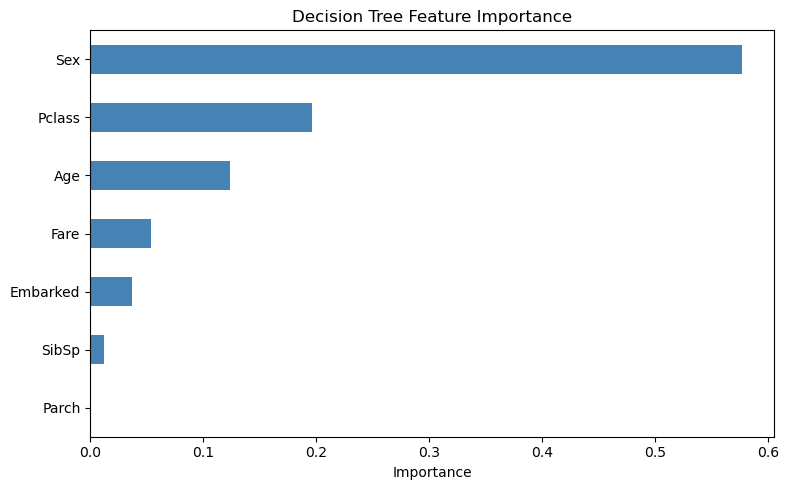

Sex         0.576297
Pclass      0.195920
Age         0.123665
Fare        0.054002
Embarked    0.037198
SibSp       0.012109
Parch       0.000809
dtype: float64

In [5]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances.sort_values(ascending=False)

## 6. (보너스) 랜덤포레스트와 비교

트리 하나는 데이터가 조금만 바뀌어도 구조가 크게 흔들릴 수 있습니다 (분산이 큼). 여러 트리를 앙상블한 **랜덤포레스트**를 같이 학습시켜서 성능과 변수 중요도가 어떻게 달라지는지 비교해봅니다.

Decision Tree accuracy: 0.7877
Random Forest accuracy: 0.7989


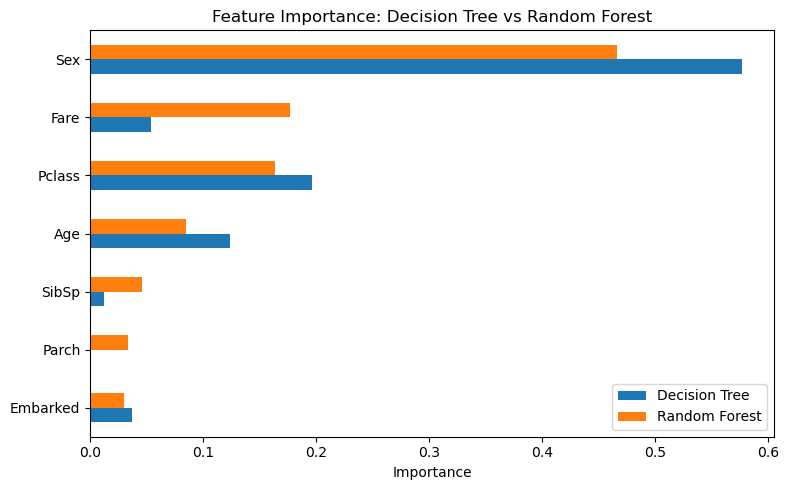

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf_model.fit(X_train, y_train)

print(f"Decision Tree accuracy: {model.score(X_test, y_test):.4f}")
print(f"Random Forest accuracy: {rf_model.score(X_test, y_test):.4f}")

rf_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

comparison = pd.DataFrame({
    'Decision Tree': importances,
    'Random Forest': rf_importances,
}).sort_values('Random Forest', ascending=True)

comparison.plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importance: Decision Tree vs Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. `feature_importances_` vs SHAP — 같은 결과일까?

`feature_importances_`(gini importance)와 SHAP은 "중요도"를 다르게 정의합니다.

- **gini importance**: 훈련 데이터 기준, 트리가 분기할 때마다 그 변수가 불순도(gini)를 얼마나 줄였는지 합산. 연속형 변수(Age, Fare)는 분기 후보가 많아서 과대평가되는 편향이 있다고 알려져 있습니다.
- **SHAP**: 테스트 데이터의 개별 예측마다 "이 변수가 없었다면 예측이 얼마나 달라졌을까"를 게임이론적으로 계산해서 평균낸 값. 실제 예측 기여도에 더 가깝습니다.

같은 결정 트리 모델에 두 방법을 모두 적용해서 순위가 얼마나 다른지 비교해봅니다.

In [7]:
import numpy as np
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 이진 분류에서 shap 버전에 따라 (n_samples, n_features) 또는 (n_samples, n_features, n_classes)로 나올 수 있음
sv_survived = shap_values[1] if isinstance(shap_values, list) else (
    shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
)

mean_abs_shap = pd.Series(np.abs(sv_survived).mean(axis=0), index=X_test.columns)

comparison_gini_shap = pd.DataFrame({
    'Gini importance': importances,
    'Mean |SHAP|': mean_abs_shap,
})
comparison_gini_shap['Gini rank'] = comparison_gini_shap['Gini importance'].rank(ascending=False).astype(int)
comparison_gini_shap['SHAP rank'] = comparison_gini_shap['Mean |SHAP|'].rank(ascending=False).astype(int)

comparison_gini_shap.sort_values('Gini rank')

,Gini importance,Mean |SHAP|,Gini rank,SHAP rank
Sex,0.576297,0.235398,1,1
Pclass,0.195920,0.113793,2,2
Age,0.123665,0.032609,3,4
Fare,0.054002,0.044218,4,3
Embarked,0.037198,0.023585,5,5
SibSp,0.012109,0.007950,6,6
Parch,0.000809,0.002184,7,7


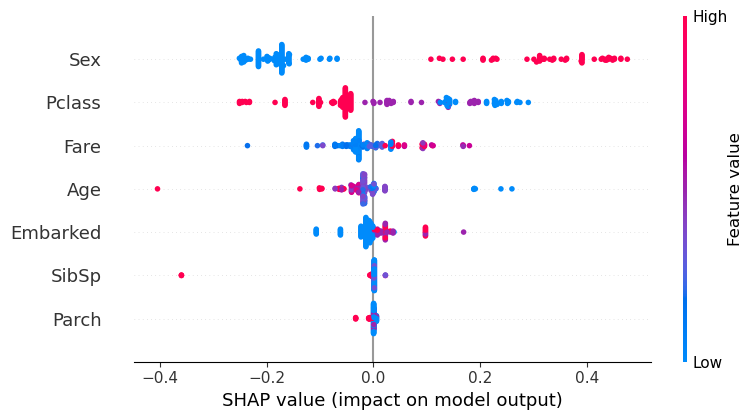

In [8]:
shap.summary_plot(sv_survived, X_test)

## 8. 부스팅(Boosting) 앙상블 — XGBoost

RandomForest는 트리들을 **독립적으로** 여러 개 만들어서 평균내는 배깅(bagging) 방식입니다.

부스팅은 이와 다르게 트리를 **순차적으로** 만들면서, 이전 트리가 못 맞춘 부분(오차)을 다음 트리가 보완하도록 학습합니다. 정형 데이터에서는 보통 배깅보다 부스팅(XGBoost, LightGBM, CatBoost)이 더 높은 성능을 냅니다.

지금까지 만든 Decision Tree, Random Forest와 성능 및 변수 중요도를 함께 비교해봅니다.

Decision Tree accuracy:  0.7877
Random Forest accuracy:  0.7989
XGBoost accuracy:        0.8156


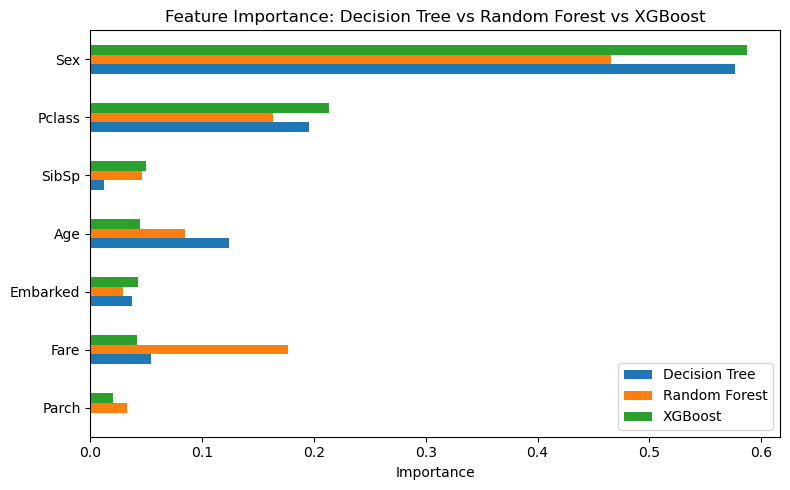

In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
)
xgb_model.fit(X_train, y_train)

print(f"Decision Tree accuracy:  {model.score(X_test, y_test):.4f}")
print(f"Random Forest accuracy:  {rf_model.score(X_test, y_test):.4f}")
print(f"XGBoost accuracy:        {xgb_model.score(X_test, y_test):.4f}")

xgb_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

importance_all = pd.DataFrame({
    'Decision Tree': importances,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances,
}).sort_values('XGBoost', ascending=True)

importance_all.plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importance: Decision Tree vs Random Forest vs XGBoost')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. 여러 모델을 직접 앙상블하기 — Voting

RandomForest나 XGBoost는 "같은 종류의 모델(트리)"을 여러 개 묶은 앙상블입니다. 이번엔 **서로 다른 종류의 모델**(로지스틱 회귀, 결정 트리, 랜덤포레스트)을 직접 묶어서 앙상블의 원리를 체감해봅니다.

`VotingClassifier`는 각 모델의 예측을 모아서 다수결(hard) 또는 예측 확률의 평균(soft)으로 최종 예측을 만듭니다. 서로 다른 모델은 서로 다른 종류의 오류를 만드는 경향이 있어서, 잘 섞이면 개별 모델보다 더 안정적인 성능이 나올 수 있습니다.

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier

logreg_model = LogisticRegression(random_state=42, max_iter=1000)

voting_model = VotingClassifier(
    estimators=[
        ('logreg', logreg_model),
        ('tree', DecisionTreeClassifier(max_depth=4, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)),
    ],
    voting='soft',
)
voting_model.fit(X_train, y_train)

print(f"Logistic Regression accuracy: {logreg_model.fit(X_train, y_train).score(X_test, y_test):.4f}")
print(f"Decision Tree accuracy:       {model.score(X_test, y_test):.4f}")
print(f"Random Forest accuracy:       {rf_model.score(X_test, y_test):.4f}")
print(f"XGBoost accuracy:             {xgb_model.score(X_test, y_test):.4f}")
print(f"Voting (soft) accuracy:       {voting_model.score(X_test, y_test):.4f}")

Logistic Regression accuracy: 0.8045
Decision Tree accuracy:       0.7877
Random Forest accuracy:       0.7989
XGBoost accuracy:             0.8156
Voting (soft) accuracy:       0.8156


## 정리

| 모델 | Accuracy |
|---|---|
| Decision Tree | 0.7877 |
| Random Forest (배깅) | 0.7989 |
| XGBoost (부스팅) | 0.8156 |
| Voting (soft, 이종 모델 3개) | 0.8156 |
| Stacking (이종 모델 3개 + 메타 모델) | 0.8268 |

- 트리 하나보다 앙상블(배깅/부스팅/직접 조합)이 대체로 더 낫습니다.
- 실무에서 "앙상블"은 보통 XGBoost/LightGBM/CatBoost 같은 **부스팅 모델 하나**로 대체해서 쓰는 경우가 많습니다 (튜닝 대상이 하나라 다루기 쉽고, 대체로 배깅보다 성능이 좋음).
- 서로 다른 종류의 모델을 직접 묶는 Voting/Stacking은 튜닝이 더 번거롭지만, 이번처럼 부스팅 하나보다 더 좋은 성능이 나올 수도 있습니다 — 특히 모델들이 서로 다른 종류의 오류를 만들 때 효과적입니다.